# WISER: Rare Event Probabilities Sampler

In [8]:
!pip install qiskit pylatexenc matplotlib

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import matplotlib.pyplot as plt
!pip install qiskit qiskit-aer pylatexenc matplotlib
from qiskit import transpile

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from collections import Counter
import matplotlib.pyplot as plt
import random

In [4]:
import math
from math import comb

def first_passage_prob_exact(D, T, p):
    if T < D:
        return 0.0
    # parity: only times t with same parity as D contribute
    total = 0.0
    for t in range(D, T + 1):
        if (t - D) % 2 != 0:
            continue
        k = (t + D) // 2
        total += (D / t) * comb(t, k) * (p ** k) * ((1 - p) ** (t - k))
    return total

print(first_passage_prob_exact(D=1074, T=1075, p=0.5))

#D=1074,T=1075,p=0.5, you are essentially at the edge of what float64 can representr

5e-324


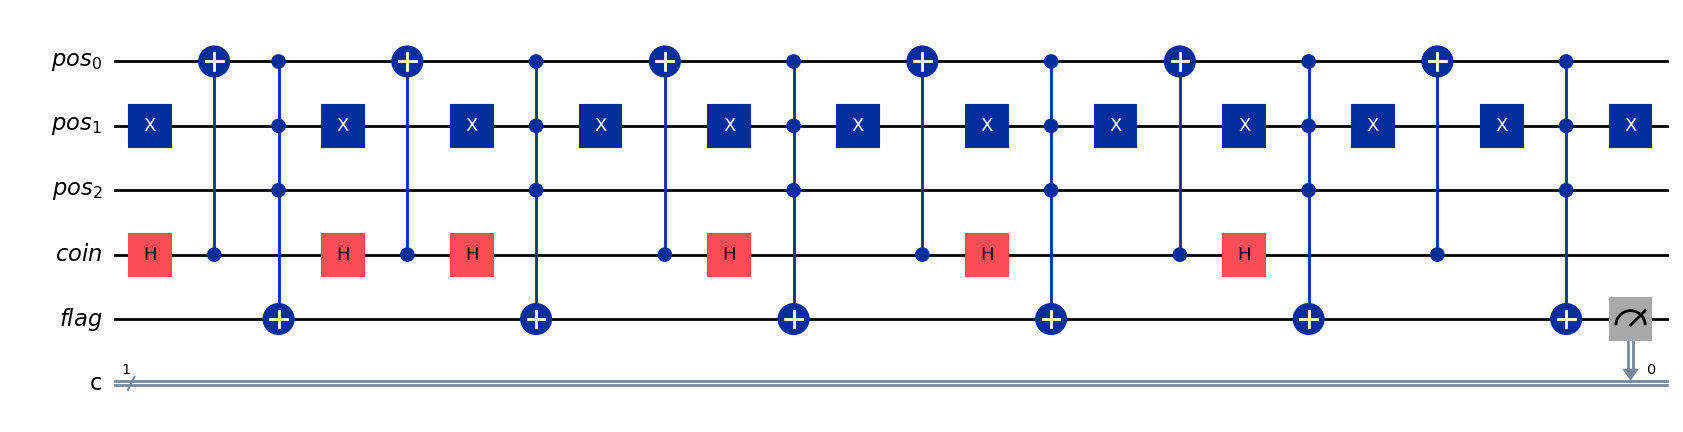

In [13]:
T = 6
D = 5
shots = 200000


pos = QuantumRegister(3, "pos")
coin = QuantumRegister(1, "coin")
flag = QuantumRegister(1, "flag")
c = ClassicalRegister(1, "c")

qc = QuantumCircuit(pos, coin, flag, c)


for t in range(T):
    # coin flip
    qc.h(coin[0])

    # simplified conditional step:
    # if coin = 1, flip least significant position bit
    qc.cx(coin[0], pos[0])

    # detect boundary D = 5 = |101>
    qc.x(pos[1])  # convert middle bit condition 0 into control-on-1
    qc.mcx([pos[0], pos[1], pos[2]], flag[0])
    qc.x(pos[1])

qc.measure(flag[0], c[0])

qc.draw("mpl", fold=-1, style="iqp")


In [15]:
shots = 200000
T = 6

path = QuantumRegister(T, "path")
flag = QuantumRegister(1, "flag")
c = ClassicalRegister(1, "c")

qc = QuantumCircuit(path, flag, c)

for i in range(T):
    qc.h(path[i])

qc.mcx(path, flag[0])

qc.measure(flag[0], c[0])

sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=shots).result()
counts = result.get_counts()

quantum_prob = counts.get("1", 0) / shots

print(counts)
print("Quantum estimated P(flag=1) =", quantum_prob)
print("Expected probability =", 1 / (2**T))

{'1': 3112, '0': 196888}
Quantum estimated P(flag=1) = 0.01556
Expected probability = 0.015625


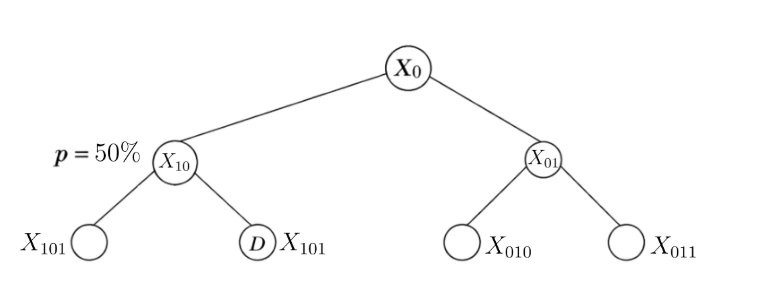

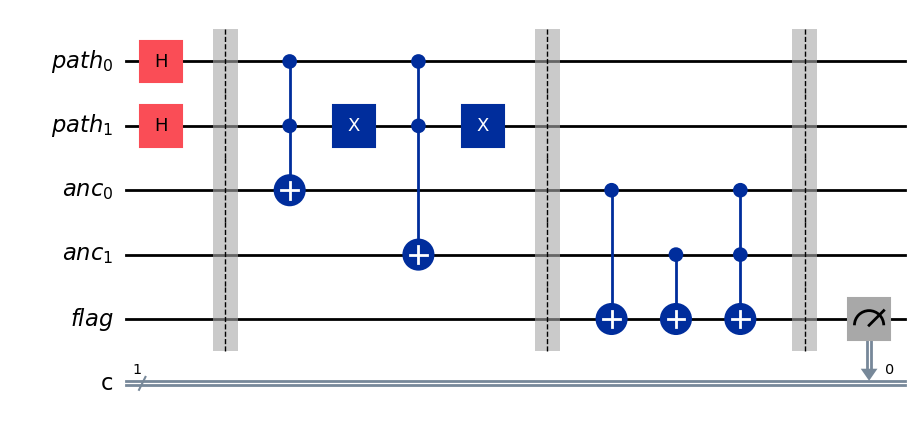

In [12]:
path = QuantumRegister(2, "path")
anc = QuantumRegister(2, "anc")
flag = QuantumRegister(1, "flag")
c = ClassicalRegister(1, "c")
qc = QuantumCircuit(path, anc, flag, c)

qc.h(path[0])
qc.h(path[1])

qc.barrier()

qc.ccx(path[0], path[1], anc[0])
qc.x(path[1])
qc.ccx(path[0], path[1], anc[1])
qc.x(path[1])

qc.barrier()

qc.cx(anc[0], flag[0])
qc.cx(anc[1], flag[0])
qc.ccx(anc[0], anc[1], flag[0])

qc.barrier()

qc.measure(flag[0], c[0])

qc.draw("mpl", fold=-1, style="iqp")


In [16]:
shots = 10000
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=shots).result()
counts = result.get_counts()
print(counts)

{'1': 168, '0': 9832}


In [17]:
D = 5
rare_path = "11111"
shots = 20000

path = QuantumRegister(D, "path")
anc = QuantumRegister(max(D - 1, 1), "anc")
flag = QuantumRegister(1, "flag")
c = ClassicalRegister(1, "c")

qc = QuantumCircuit(path, anc, flag, c)

for i in range(D):
    qc.h(path[i])

qc.barrier()

for i, bit in enumerate(rare_path):
    if bit == "0":
        qc.x(path[i])

if D == 1:
    qc.cx(path[0], flag[0])
else:
    qc.ccx(path[0], path[1], anc[0])
    for i in range(2, D):
        qc.ccx(path[i], anc[i - 2], anc[i - 1])

    #  rare-event flag
    qc.cx(anc[D - 2], flag[0])

qc.barrier()

for i, bit in enumerate(rare_path):
    if bit == "0":
        qc.x(path[i])

qc.barrier()
qc.measure(flag[0], c[0])

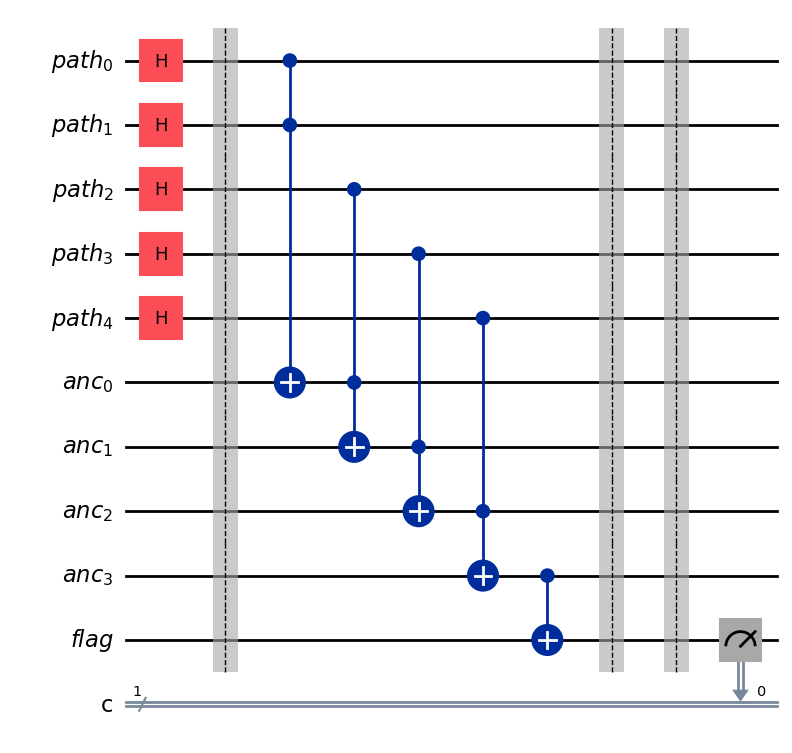

In [18]:
qc.draw("mpl", fold=-1, style="iqp")

In [19]:

# classical probability
classical_prob = 1 / (2 ** D)

print(f"Depth D = {D}")
print(f"Rare path = {rare_path}")
print(f"Classical exact P(flag=1) = {classical_prob:.8f}")

# quantum simulation
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=shots).result()
counts = result.get_counts()

quantum_prob = counts.get("1", 0) / shots

print("\nQuantum measurement counts:")
print(counts)
print(f"Quantum estimated P(flag=1) = {quantum_prob:.8f}")
print(f"Absolute error = {abs(classical_prob - quantum_prob):.8f}")

Depth D = 5
Rare path = 11111
Classical exact P(flag=1) = 0.03125000

Quantum measurement counts:
{'1': 569, '0': 19431}
Quantum estimated P(flag=1) = 0.02845000
Absolute error = 0.00280000


**Dynamic Circle Exploration**

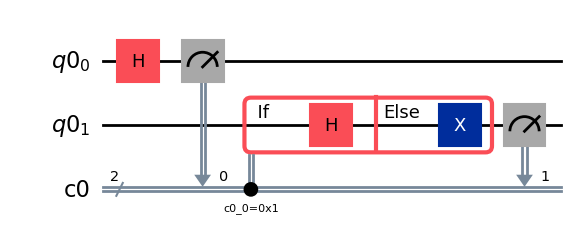

In [20]:
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0, q1) = qubits
(c0, c1) = clbits

circuit.h(q0)
circuit.measure(q0, c0)
with circuit.if_test((c0, 1)) as else_:
    circuit.h(q1)
with else_:
    circuit.x(q1)
circuit.measure(q1, c1)

circuit.draw("mpl")